In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches

import os


### Seeing the spots with min expression ###

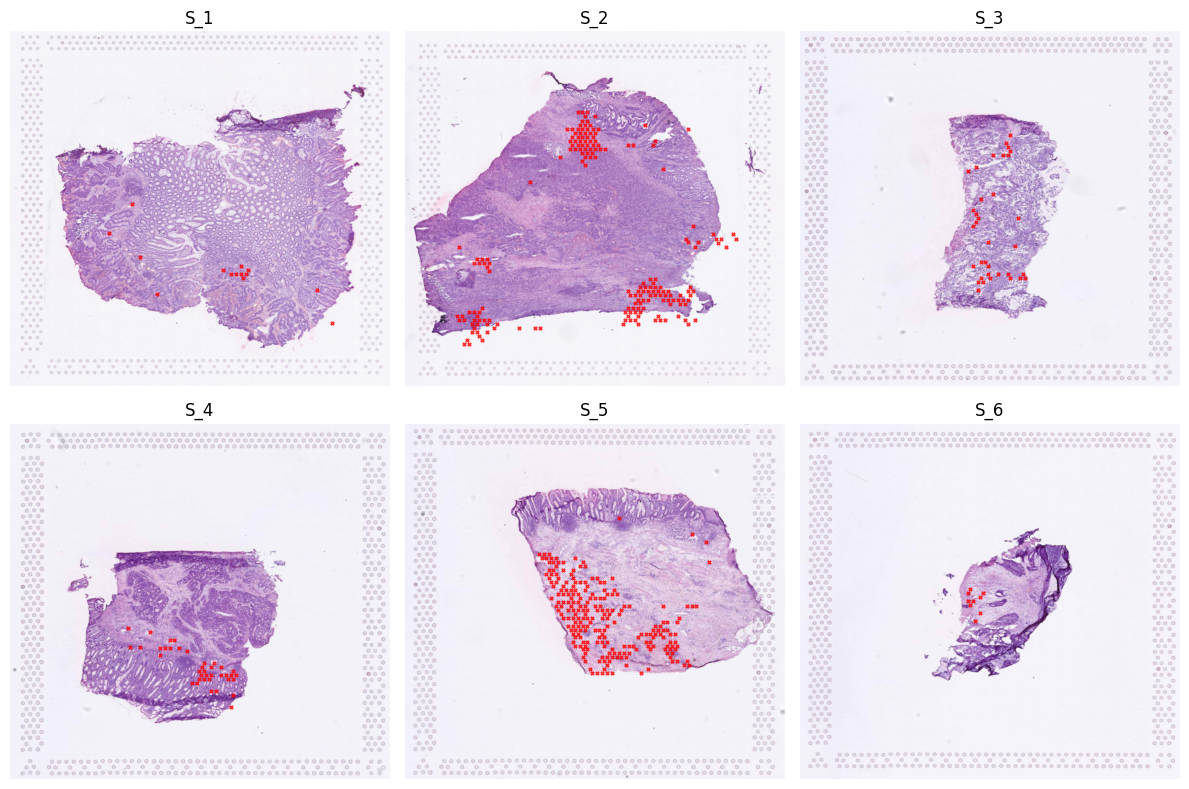

In [1]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Open the HDF5 file and load the Train images and spots datasets
with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5", "r") as h5file:
    train_images = h5file["images/Train"]
    train_spots = h5file["spots/Train"]

    # Get a list of all sample keys (slide identifiers)
    samples = list(train_images.keys())
    n_samples = len(samples)
    
    # Determine grid size (roughly square)
    cols = math.ceil(math.sqrt(n_samples))
    rows = math.ceil(n_samples / cols)
    
    # Create a figure with a grid of subplots
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    # In case there's only one subplot, make it iterable
    axs = axs.flatten() if n_samples > 1 else [axs]
    
    # Defining Threshold
    THRESHOLD = 0.2  

    

    for ax, sample in zip(axs, samples):
        image = np.array(train_images[sample])
        spots = np.array(train_spots[sample])
        x, y = spots["x"], spots["y"]

        # 
        ax.imshow(image, aspect="auto")
        #ax.scatter(x, y, color="red", s=1, alpha=0.4)

        #  C1–C35 All < THRESHOLD
        # 1) Find the field names C1–C35
        value_fields = [f"C{i}" for i in range(1, 36)]
        # 2) Retrieve an array of (n_spots,35)
        values = np.stack([spots[field] for field in value_fields], axis=1)
        # 3) Mark as long as all columns in the row < threshold
        mask = np.all(values < THRESHOLD, axis=1)
        # 4) Corresponding x,y
        x_bad = spots["x"][mask]
        y_bad = spots["y"][mask]
        # 5) Image quality
        ax.scatter(x_bad, y_bad, color="red", s=5, marker="x", alpha=0.8)

        ax.axis('off')
        ax.set_title(sample)
        
    # Hide any unused subplots (if the grid is larger than needed)
    for ax in axs[len(samples):]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()

### Quality of the Images ###

In [2]:
import os
import h5py
import cv2
import numpy as np
import pandas as pd

def image_quality_metrics_nonzero(img):
    """
    Compute QC metrics only over pixels where any channel > 0.
    Returns:
      mean (3,), std (3,), pct_under, pct_over, sharpness, noise_metric
    """
    # Convert to float and normalize to [0,1]
    img_f = img.astype(np.float32)
    if img_f.max() > 1.5:
        img_f /= img_f.max()

    # Construct mask：Keep only pixels with any one of the three channels > 0
    # mask shape: [H, W]
    mask = (img_f > 0).any(axis=2)

    # Extract the 3 channel values of non zero pixels，shape = [N, 3]
    pix = img_f[mask]

    # Calculate mean / std
    mean = pix.mean(axis=0)
    std  = pix.std(axis=0)

    # under/over-exposed fractions
    pct_under = (pix < 10/255).mean()
    pct_over  = (pix > 245/255).mean()

    # For sharpness and noise，a grayscale image needs to be created first, and then only the mask area needs to be calculated
    gray_full = cv2.cvtColor((img_f*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    gray = gray_full.copy()
    gray[~mask] = 0   # Set the background (zero intensity) pixels to 0 to ignore them

    sharp = cv2.Laplacian(gray, cv2.CV_32F).var()
    blur  = cv2.GaussianBlur(gray, (5,5), 0)
    noise = np.abs(gray.astype(np.float32) - blur)[mask].mean()

    return mean, std, pct_under, pct_over, sharp, noise

# Run examples in batches
file_path = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try1_masked.h5"

records = []
with h5py.File(file_path, "r") as h5:
    for split in ["Train", "Test"]:
        imgs = h5[f"images/{split}"]
        for slide_id in imgs.keys():
            img = np.array(imgs[slide_id])
            m, s, u, o, sh, nz = image_quality_metrics_nonzero(img)
            records.append({
                "split": split,
                "slide": slide_id,
                "mean_R": m[0], "mean_G": m[1], "mean_B": m[2],
                "std_R":  s[0], "std_G":  s[1], "std_B":  s[2],
                "pct_underexp": u,
                "pct_overexp":  o,
                "sharpness":    sh,
                "noise_metric": nz
            })

df = pd.DataFrame(records).round(4)
print(df)

   split slide  mean_R  mean_G  mean_B   std_R   std_G   std_B  pct_underexp  \
0  Train   S_1  0.6951  0.5379  0.7584  0.1487  0.1845  0.1235        0.0000   
1  Train   S_2  0.6375  0.4606  0.7130  0.1398  0.1787  0.1162        0.0000   
2  Train   S_3  0.6861  0.5452  0.7468  0.1819  0.2225  0.1513        0.0005   
3  Train   S_4  0.6620  0.5144  0.7276  0.1656  0.2082  0.1372        0.0000   
4  Train   S_5  0.7274  0.5890  0.7817  0.1592  0.1881  0.1336        0.0005   
5  Train   S_6  0.6940  0.5801  0.7475  0.1966  0.2342  0.1677        0.0040   
6   Test   S_7  0.6992  0.5549  0.7587  0.1485  0.1809  0.1234        0.0000   

   pct_overexp    sharpness  noise_metric  
0       0.0174  3053.178223        9.3089  
1       0.0123  2928.375488        7.6806  
2       0.0381  3346.491943       12.0187  
3       0.0211  2920.907471        9.5170  
4       0.0345  3028.010986        8.5135  
5       0.0320  2311.003174       12.0958  
6       0.0165  2562.069092        8.4640  


### Re-Allignment ###

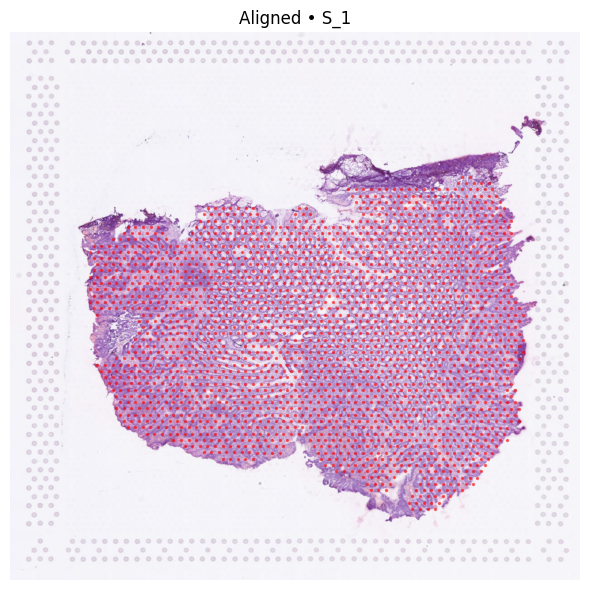

In [8]:
import sys

sys.path.append(r"C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project")
from scripts.realignment import (
    align_and_plot,
    SpotArray
)
import pathlib
import numpy as np
import h5py

h5_path           = pathlib.Path("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5")
slide_id          = "S_1"         
dx, dy            = -55, -60           # Translation value
spot_diameter_px  = 2                

# ----------Read HDF5 & Execute ---------- #
if not h5_path.exists():
    raise FileNotFoundError(h5_path)

with h5py.File(h5_path, "r") as h5:
    img  = np.array(h5["images/Train"][slide_id])
    rec  = np.array(h5["spots/Train"][slide_id])
    raw_spots = SpotArray(x=rec["x"], y=rec["y"])

aligned_spots = align_and_plot(
    image=img,
    spots=raw_spots,
    dx=dx, dy=dy,
    spot_diameter_px=spot_diameter_px,
    title=f"Aligned • {slide_id}"
)

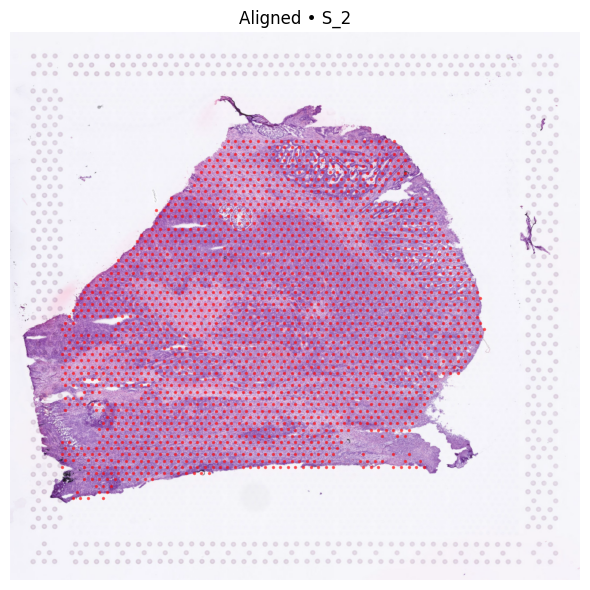

In [9]:

h5_path           = pathlib.Path("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5")
slide_id          = "S_2"          
dx, dy            = -90, -60        
spot_diameter_px  = 2                 

if not h5_path.exists():
    raise FileNotFoundError(h5_path)

with h5py.File(h5_path, "r") as h5:
    img  = np.array(h5["images/Train"][slide_id])
    rec  = np.array(h5["spots/Train"][slide_id])
    raw_spots = SpotArray(x=rec["x"], y=rec["y"])

aligned_spots = align_and_plot(
    image=img,
    spots=raw_spots,
    dx=dx, dy=dy,
    spot_diameter_px=spot_diameter_px,
    title=f"Aligned • {slide_id}"
)

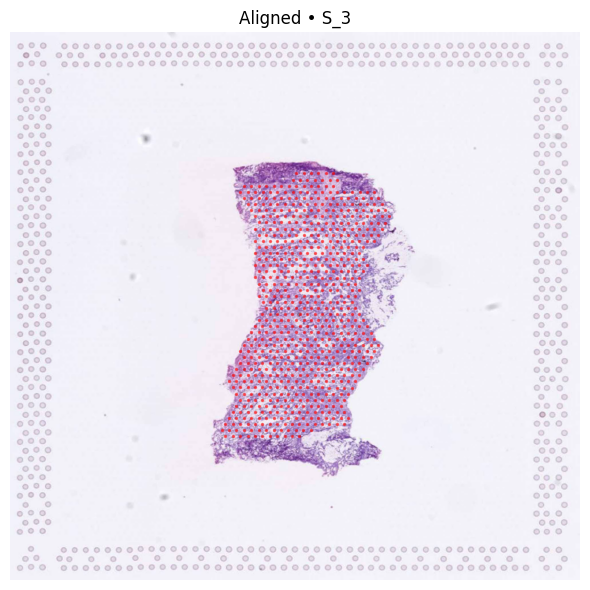

In [11]:
h5_path           = pathlib.Path("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5")
slide_id          = "S_3"         
dx, dy            = -25, -25          
spot_diameter_px  = 2                 


if not h5_path.exists():
    raise FileNotFoundError(h5_path)

with h5py.File(h5_path, "r") as h5:
    img  = np.array(h5["images/Train"][slide_id])
    rec  = np.array(h5["spots/Train"][slide_id])
    raw_spots = SpotArray(x=rec["x"], y=rec["y"])

aligned_spots = align_and_plot(
    image=img,
    spots=raw_spots,
    dx=dx, dy=dy,
    spot_diameter_px=spot_diameter_px,
    title=f"Aligned • {slide_id}"
)

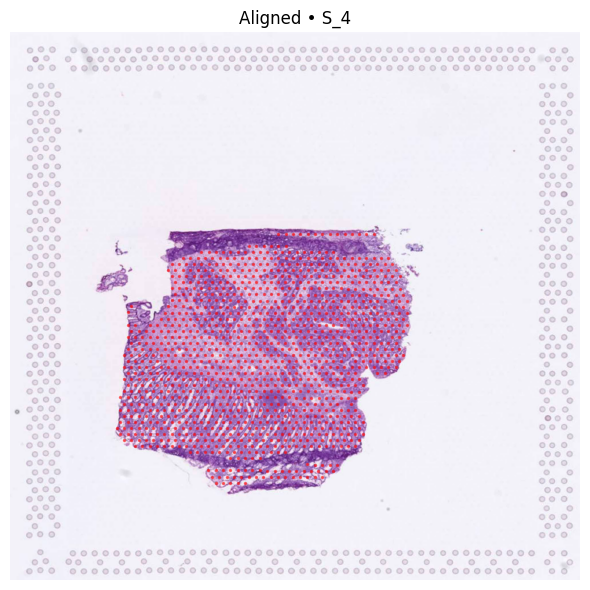

In [13]:

h5_path           = pathlib.Path("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5")
slide_id          = "S_4"         
dx, dy            = -15, -15        
spot_diameter_px  = 2                 


if not h5_path.exists():
    raise FileNotFoundError(h5_path)

with h5py.File(h5_path, "r") as h5:
    img  = np.array(h5["images/Train"][slide_id])
    rec  = np.array(h5["spots/Train"][slide_id])
    raw_spots = SpotArray(x=rec["x"], y=rec["y"])

aligned_spots = align_and_plot(
    image=img,
    spots=raw_spots,
    dx=dx, dy=dy,
    spot_diameter_px=spot_diameter_px,
    title=f"Aligned • {slide_id}"
)

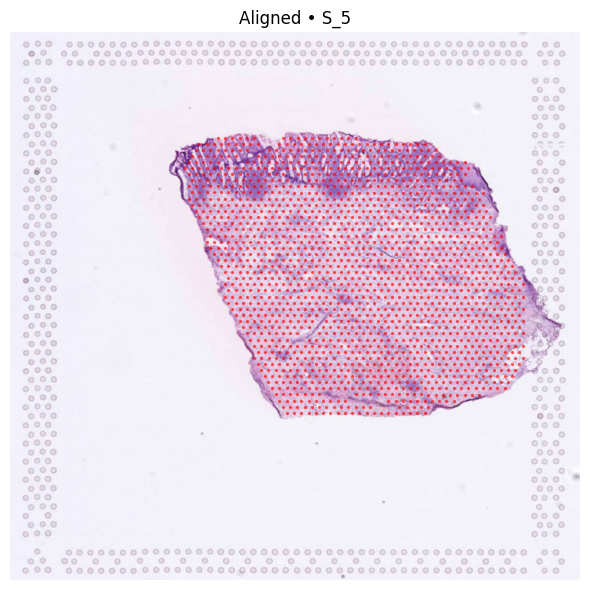

In [14]:

h5_path           = pathlib.Path("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5")
slide_id          = "S_5"          
dx, dy            = -15, -15        
spot_diameter_px  = 2                 


if not h5_path.exists():
    raise FileNotFoundError(h5_path)

with h5py.File(h5_path, "r") as h5:
    img  = np.array(h5["images/Train"][slide_id])
    rec  = np.array(h5["spots/Train"][slide_id])
    raw_spots = SpotArray(x=rec["x"], y=rec["y"])

aligned_spots = align_and_plot(
    image=img,
    spots=raw_spots,
    dx=dx, dy=dy,
    spot_diameter_px=spot_diameter_px,
    title=f"Aligned • {slide_id}"
)

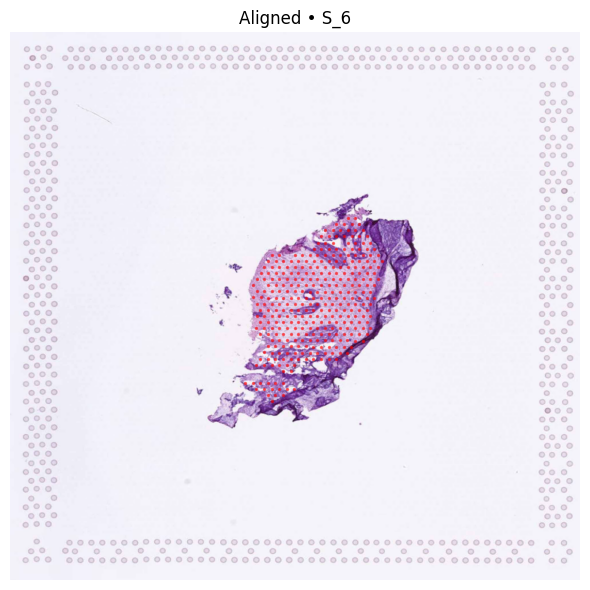

In [15]:

h5_path           = pathlib.Path("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5")
slide_id          = "S_6"         
dx, dy            = -30, -30          
spot_diameter_px  = 2                


if not h5_path.exists():
    raise FileNotFoundError(h5_path)

with h5py.File(h5_path, "r") as h5:
    img  = np.array(h5["images/Train"][slide_id])
    rec  = np.array(h5["spots/Train"][slide_id])
    raw_spots = SpotArray(x=rec["x"], y=rec["y"])

aligned_spots = align_and_plot(
    image=img,
    spots=raw_spots,
    dx=dx, dy=dy,
    spot_diameter_px=spot_diameter_px,
    title=f"Aligned • {slide_id}"
)

In [16]:
# ------------------------------------------------------------
# Copy all slides, but translate spots for specified slides only
# ------------------------------------------------------------
from __future__ import annotations
import numpy as np
import h5py
import pathlib

# ---------- Path setup ---------- #
src_h5 = pathlib.Path("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5")
dst_h5 = pathlib.Path("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Spot_preprocessing\\re_alligned.h5")
dst_h5.parent.mkdir(parents=True, exist_ok=True)  # Ensure output directory exists

# ---------- Slide-specific offsets ---------- #
slide_offsets: dict[str, tuple[float, float]] = {
    "S_1": (-55, -60),
    "S_2": (-90, -60),
    "S_3": (-25, -25),
    "S_4": (-15, -15),
    "S_5": (-15, -15),
    "S_6": (-30, -30),
}
# # (Alternatively, only adjust S_1 and S_2)
# slide_offsets = {
#     "S_1": (-55, -60),
#     "S_2": (-90, -60),
# }

# ---------- Read source and write destination ---------- #
with h5py.File(src_h5, "r") as src, h5py.File(dst_h5, "w") as dst:
    img_src  = src["images/Train"]
    spot_src = src["spots/Train"]
    img_dst  = dst.create_group("images/Train")
    spot_dst = dst.create_group("spots/Train")

    # ---- Copy all images ---- #
    for slide in img_src.keys():
        img_dst.create_dataset(
            slide,
            data=np.array(img_src[slide]),
            compression="gzip"
        )

    # ---- Process & copy all spots ---- #
    for slide in spot_src.keys():
        rec = np.array(spot_src[slide])           # structured array
        if slide in slide_offsets:
            dx, dy = slide_offsets[slide]
            rec = rec.copy()                      # avoid modifying source buffer
            rec["x"] = rec["x"] + dx
            rec["y"] = rec["y"] + dy
        spot_dst.create_dataset(
            slide,
            data=rec,
            dtype=rec.dtype,
            compression="gzip"
        )

print(
    "✅ Done! All images and spots have been written to:\n"
    f"   {dst_h5}\n"
    "   (Applied translation to spots for slides: "
    + ", ".join(slide_offsets.keys()) + ")"
)

✅ Done! All images and spots have been written to:
   C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\data_preprocessing\Spot_preprocessing\re_alligned.h5
   (Applied translation to spots for slides: S_1, S_2, S_3, S_4, S_5, S_6)
